In [2]:
import json
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
from wordcloud import WordCloud
from tqdm.notebook import tqdm

In [3]:
input_file='../data/processed/tokenized.jsonl'

## Read data and statistic

In [4]:
article_lengths=[]
word_counter=Counter()
total_articles=0

with open(input_file,'r',encoding="utf8") as f:
    for line in tqdm(f.readlines()):
        if not line.strip():
            continue
        
        try:
            data=json.loads(line)
            text = data.get('title', '') + " " + data.get('content', '')
            tokens = text.split()
            article_lengths.append(len(tokens))
            word_counter.update(tokens)
            total_articles += 1
        except json.JSONDecodeError:
            continue
        
print(f"Sum of articles: {total_articles}")
print(f"Number of tokens: {sum(article_lengths):,}")
print(f"Number of unique words: {len(word_counter):,}")
            

  0%|          | 0/9655 [00:00<?, ?it/s]

Sum of articles: 9655
Number of tokens: 6,657,875
Number of unique words: 192,885


## Plot length histogram

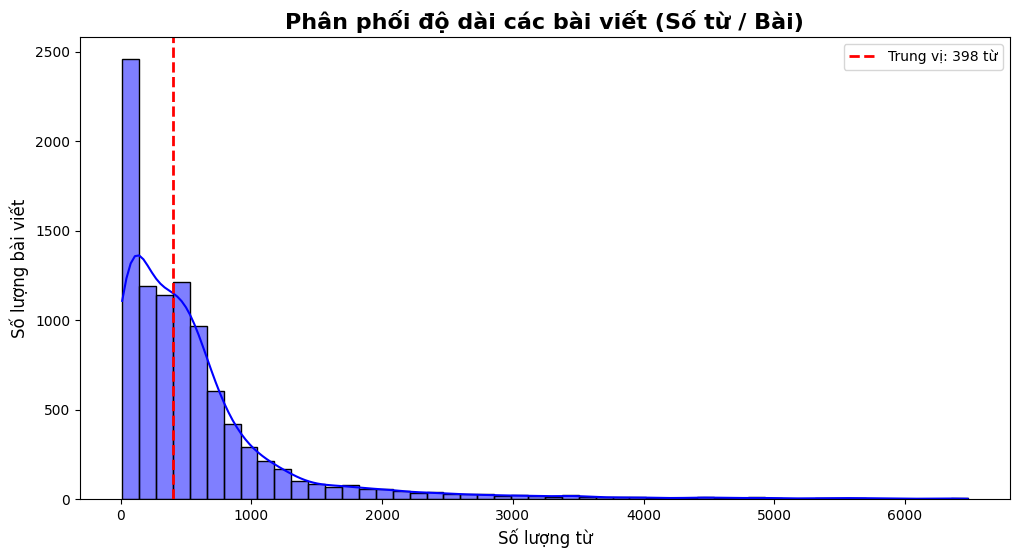

In [5]:
plt.figure(figsize=(12,6))

max_len_plt=int(np.percentile(article_lengths,99))
filter_lengths=[l for l in article_lengths if l<=max_len_plt]

sns.histplot(filter_lengths,bins=50,color='blue',kde=True)
plt.title('Phân phối độ dài các bài viết (Số từ / Bài)', fontsize=16, fontweight='bold')
plt.xlabel('Số lượng từ', fontsize=12)
plt.ylabel('Số lượng bài viết', fontsize=12)

median_length=np.median(filter_lengths)
plt.axvline(median_length, color='red', linestyle='dashed', linewidth=2, label=f'Trung vị: {median_length:.0f} từ')
plt.legend()
plt.show()

## Top 20 most frequency words

C:\Users\OS\AppData\Local\Temp\ipykernel_10372\1370870659.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts),y=list(words),palette='viridis')


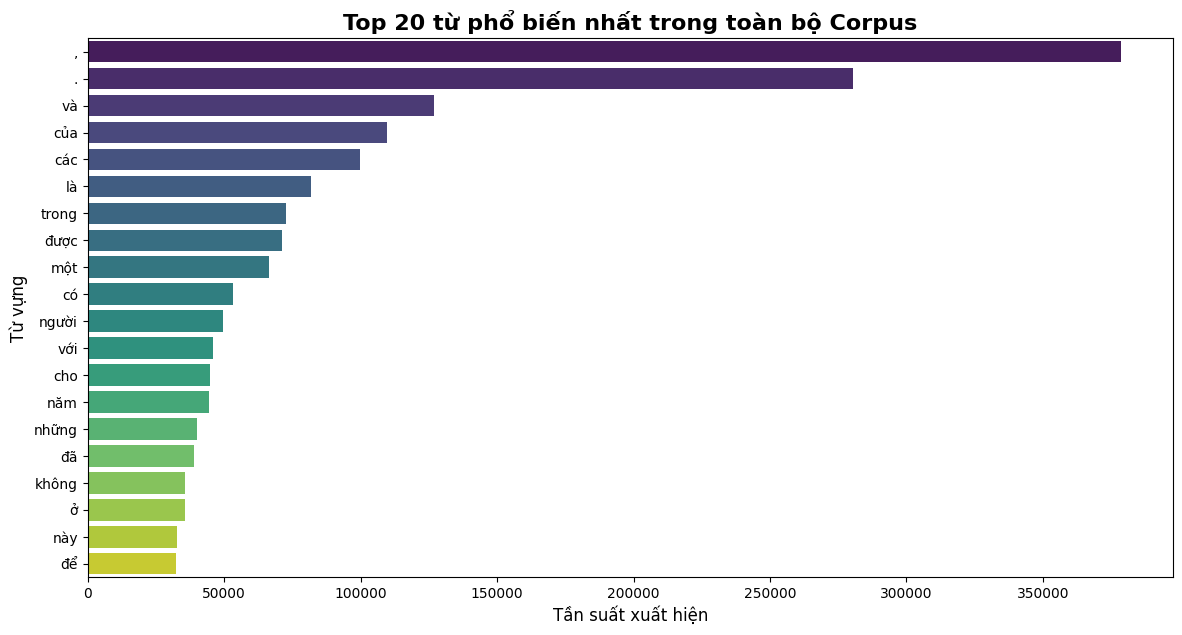

In [6]:
top=20
most_commmon=word_counter.most_common(top)
words,counts=zip(*most_commmon)

plt.figure(figsize=(14, 7))
sns.barplot(x=list(counts),y=list(words),palette='viridis')
plt.title(f'Top {top} từ phổ biến nhất trong toàn bộ Corpus', fontsize=16, fontweight='bold')
plt.xlabel('Tần suất xuất hiện', fontsize=12)
plt.ylabel('Từ vựng', fontsize=12)
plt.show()

## Plot wordcloud

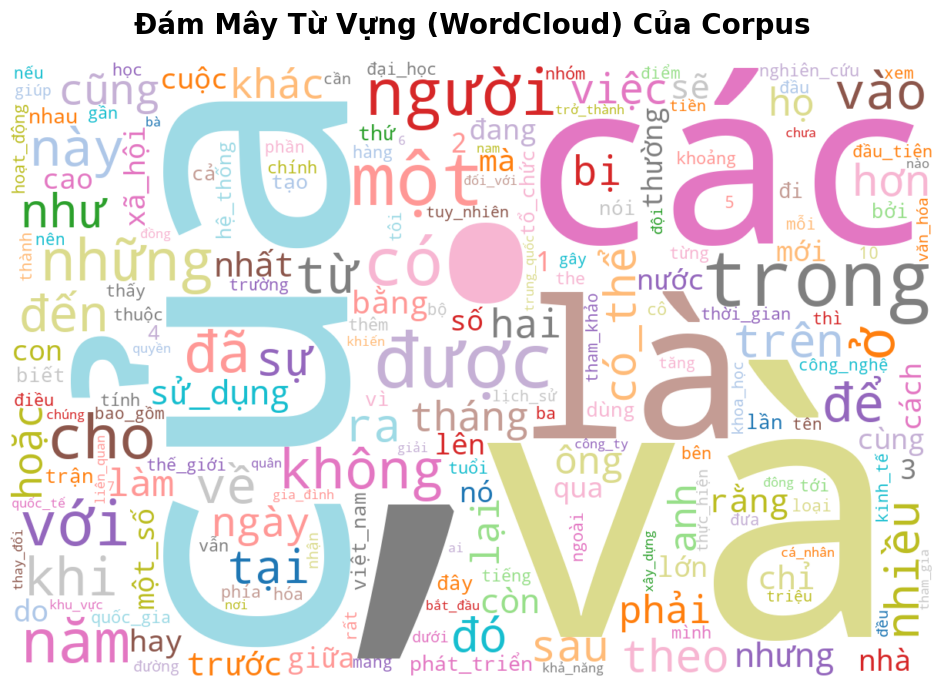

In [7]:
wordcloud=WordCloud(
    width=1200, height=800, background_color='white',colormap='tab20',max_words=200
).generate_from_frequencies(word_counter)

plt.figure(figsize=(16, 8))
plt.imshow(wordcloud,interpolation='bilinear')
plt.axis('off')
plt.title('Đám Mây Từ Vựng (WordCloud) Của Corpus', fontsize=20, fontweight='bold', pad=20)
plt.show()